<a target="_blank" href="https://colab.research.google.com/github/taobrienlbl/advanced_earth_science_data_analysis/blob/fall_2025_iub/content/lessons/11_spectral_analysis_intro/11_workalong_01_fft.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Work-along: Working with the FFT

<div style="max-width:720px"><div style="position:relative;padding-bottom:56.25%"><iframe id="kaltura_player" src='https://cdnapisec.kaltura.com/p/1751071/embedPlaykitJs/uiconf_id/55382703?iframeembed=true&amp;entry_id=1_4bwhhs1n&amp;config%5Bprovider%5D=%7B%22widgetId%22%3A%221_tbrlrim5%22%7D&amp;config%5Bplayback%5D=%7B%22startTime%22%3A0%7D'  allowfullscreen webkitallowfullscreen mozAllowFullScreen allow="autoplay *; fullscreen *; encrypted-media *" sandbox="allow-downloads allow-forms allow-same-origin allow-scripts allow-top-navigation allow-pointer-lock allow-popups allow-modals allow-orientation-lock allow-popups-to-escape-sandbox allow-presentation allow-top-navigation-by-user-activation" title="EAS-G 690 Lesson 12 - Fourier Transform Workalong 01" style="position:absolute;top:0;left:0;width:100%;height:100%;border:0"></iframe></div></div>

*Use [this link](https://iu.mediaspace.kaltura.com/media/t/1_4bwhhs1n/388761952) if you have issues viewing the embeded video above.*

This notebook explores Fourier transforms and the `numpy.fft` package on some simple examples and realistic problems.

In [1]:
""" Import libraries. """
import numpy as np 
import numpy.fft as fft
import matplotlib.pyplot as plt
import pandas as pd

# use a seaborn poster v8
plt.style.use('seaborn-v0_8-poster')


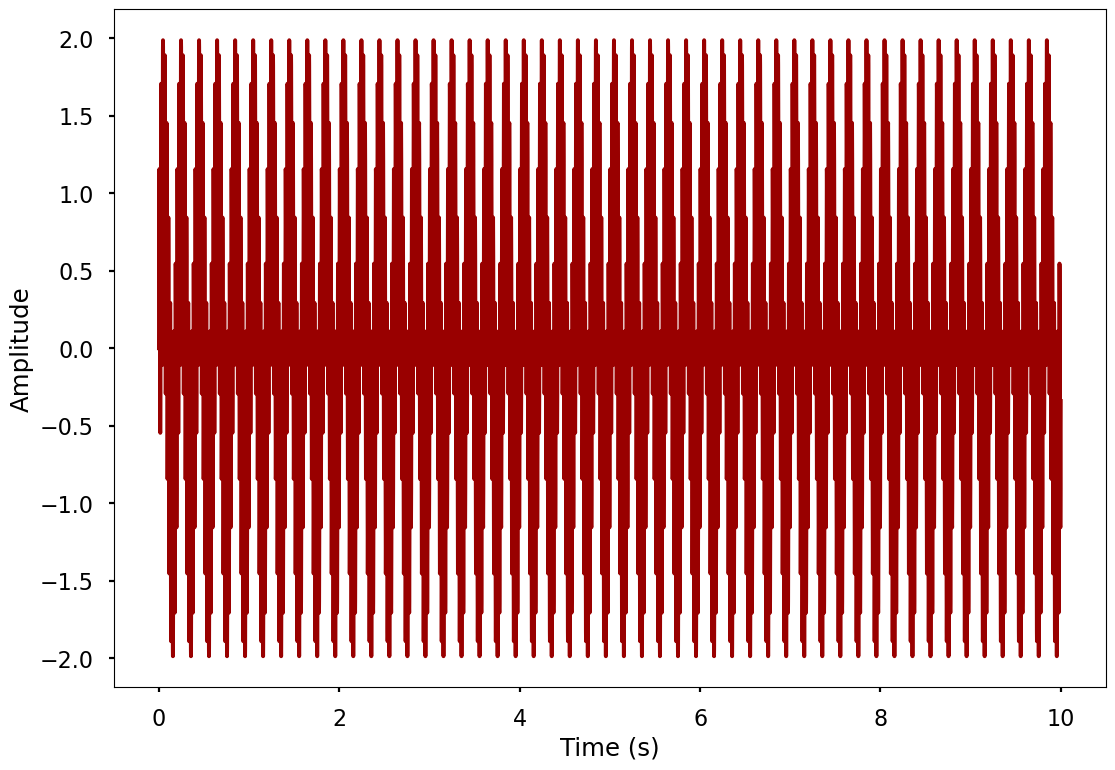

In [20]:
""" Create and plot a test signal. """

frequency = 5 #hz

# convert to radians per second
freq_rad = 2*np.pi*frequency # rad/s

# create a time variable
dt = 0.001 # seconds
t = np.arange(0,10,dt)

# create a test signal
y = np.sin(freq_rad*t) + np.sin(10*freq_rad*t)

#plot the test signal in the time domain
fig, ax = plt.subplots()

ax.plot(t, y, color = '#990000')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')

plt.show()

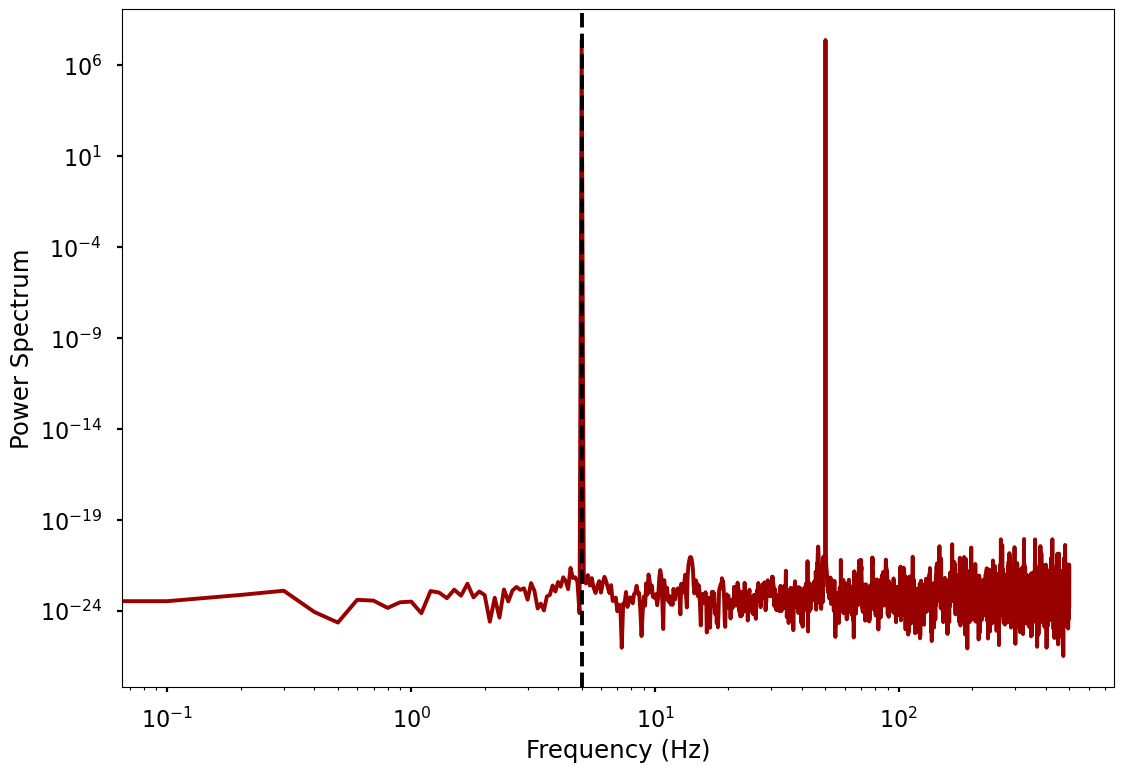

In [21]:
""" Compute the FFT of the test signal. """

#do the FFT
y_fft = fft.rfft(y) #this si c_n above (complex)

# get the power spectrum from the fft
y_power = np.abs(y_fft * np.conj(y_fft))

#get the frequencies fo the fft
freqs = fft.rfftfreq(len(y),dt)

#plot the FFT
fig, ax = plt.subplots()
ax.plot(freqs, y_power, color = '#990000')

# make the plot log-log
ax.set_xscale('log')
ax.set_yscale('log')

# add the axis labels
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectrum')

#plot a line at the frequency of the test signal
ax.axvline(frequency, color = 'black', linestyle = '--')

plt.show()

In [32]:
""" Make a function to compute the power spectrum of a signal. """

def power_spectrum(y, t):
    """ Compute the power spectrum of a signal. Returns frequencies and the power spectrum: freqs, y_power """
    #sampling rate
    dt = t[1]-t[0]
    
    #do the FFT
    y_fft = fft.rfft(y) #this si c_n above (complex)

    # get the power spectrum from the fft
    y_power = np.abs(y_fft * np.conj(y_fft))

    #get the frequencies fo the fft
    freqs = fft.rfftfreq(len(y),dt)
    
    return freqs, y_power

# also make a function for plotting
def plot_power_spectrum(freqs, y_power):
    
    """ Plots the power spectrum of a signal.  Returns the figure and axes: fig, ax """
    fig, ax = plt.subplots()
    ax.plot(freqs, y_power, color = '#990000')

    # make the plot log-log
    ax.set_xscale('log')
    ax.set_yscale('log')

    # add the axis labels
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power Spectrum')

    return fig, ax


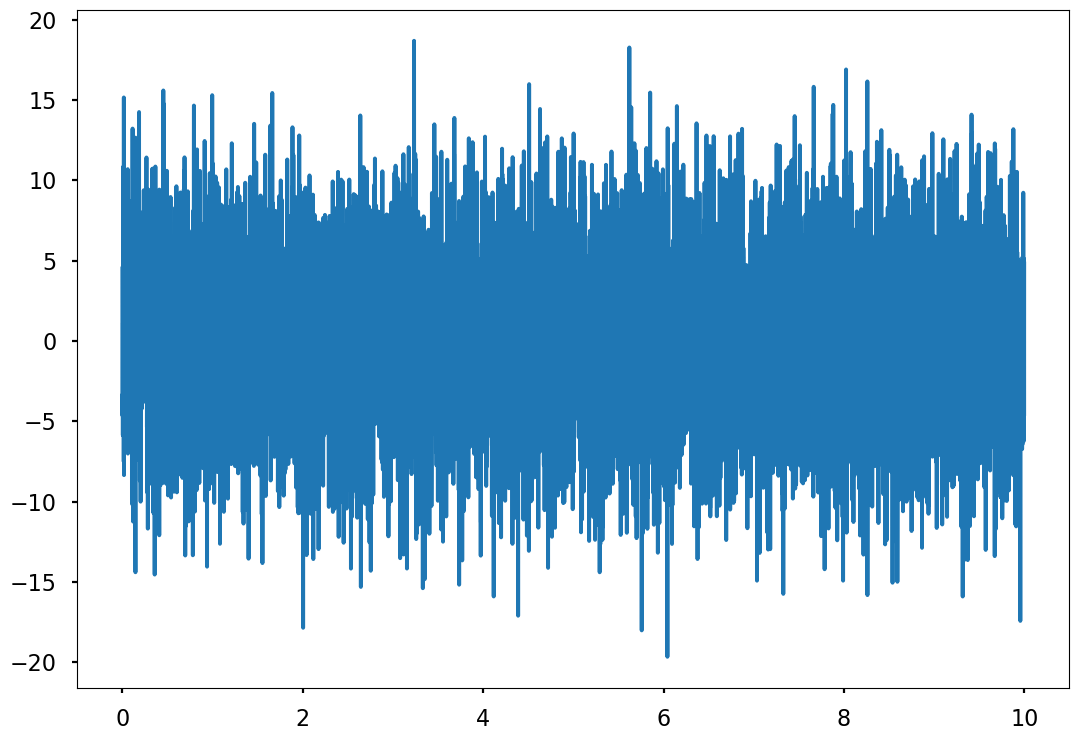

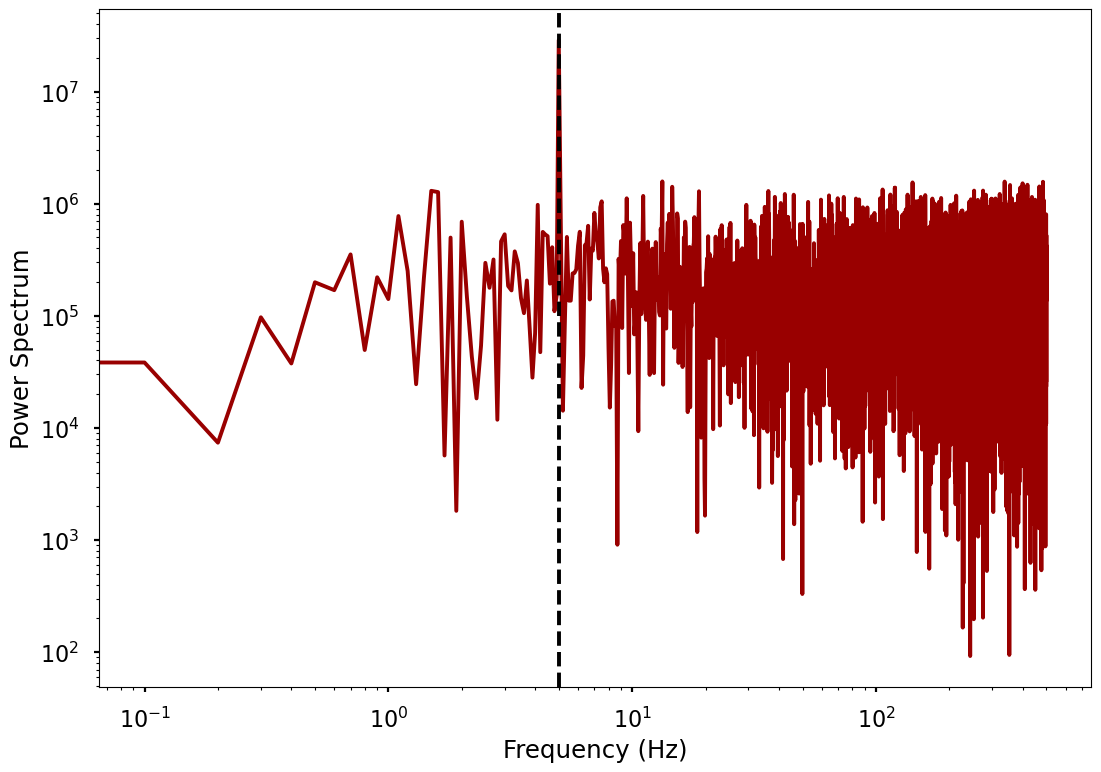

In [35]:
""" Get the power spectrum with noise added. """

#create a version of the signal with noise added
# create a test signal
y_noisy = np.sin(freq_rad*t) + np.random.normal(scale = 5, size = len(t))
plt.plot(t, y_noisy)
plt.show

freqs, y_power = power_spectrum(y_noisy,t)

fig, ax = plot_power_spectrum(freqs,y_power)

#plot a line at the frequency of the test signal
ax.axvline(frequency, color = 'black', linestyle = '--')

plt.show()


# Real data

Download this data file: https://github.com/taobrienlbl/advanced_earth_science_data_analysis/blob/fall_2025_iub/content/lessons/12_spectral_analysis/cannelton_flow.dat

The data file was obtained from https://waterdata.usgs.gov/nwis/dv/?site_no=03303280&PARAmeter_cd=00060 on 11/10/23 at about 11:16 AM Eastern.  It represents daily stream flow from 1975-present at a gauge on the Ohio River in Cannelton, IN

In [38]:
""" Load the data file. """

skiprows = 30

data = pd.read_csv(
    "./cannelton_flow.dat",
    skiprows = skiprows,
    delim_whitespace = True,
    names = ['org','id','date','flow','flag'],
    parse_dates = ['date']
)



/tmp/ipykernel_3551619/2763705121.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(


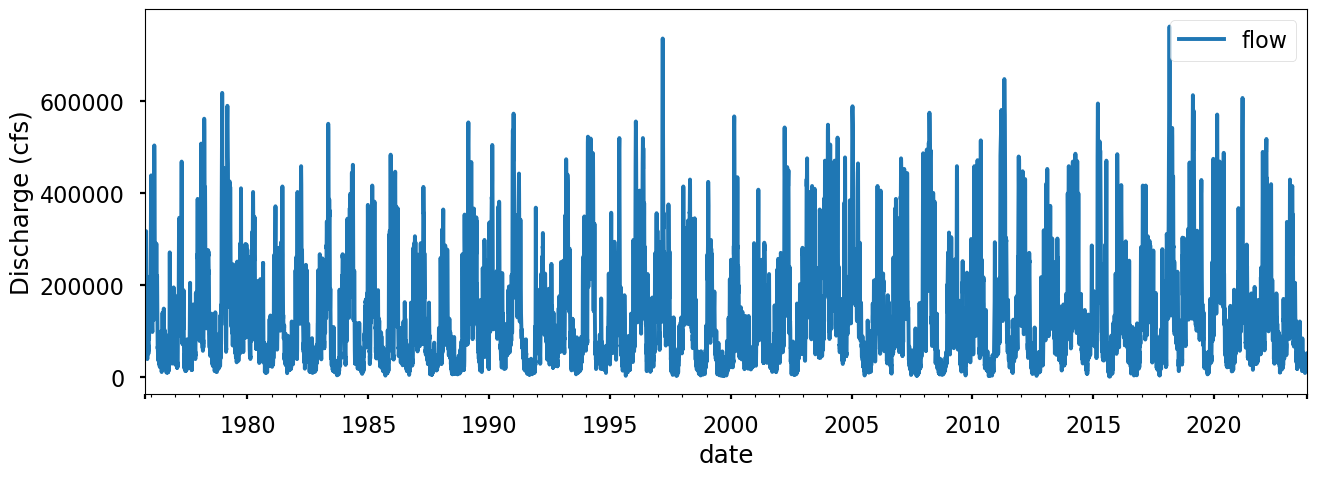

In [39]:
""" Plot a time series of the data. """

fig, ax = plt.subplots()
data.plot(ax=ax,x='date',y='flow', figsize=(15,5))
ax.set_ylabel('Discharge (cfs)')
plt.show()

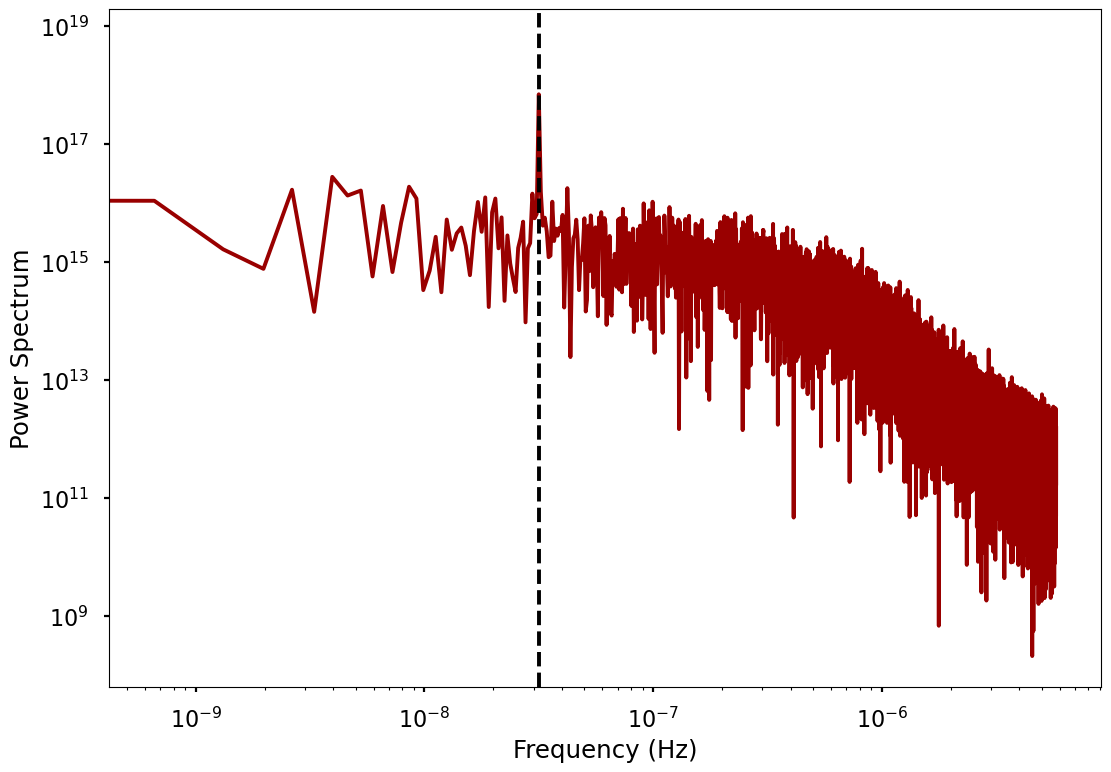

In [41]:
""" Plot the power spectrum of the data. """

#convert time to seconds
time_seconds = (data['date']-data['date'][0]).dt.total_seconds()

# get power spectrum
freqs, cfm_power = power_spectrum(data['flow'], time_seconds)

#plots power spectrum
fig, ax = plot_power_spectrum(freqs,cfm_power)

#plot a line at the frequency of the test signal
ax.axvline(1/(60*60*24*365.25), color = 'black', linestyle = '--')

plt.show()

/tmp/ipykernel_3551619/1026222509.py:12: RuntimeWarning: divide by zero encountered in divide
  fig, ax = plot_power_spectrum(1/freqs,cfm_power) #period is inverse of frequency


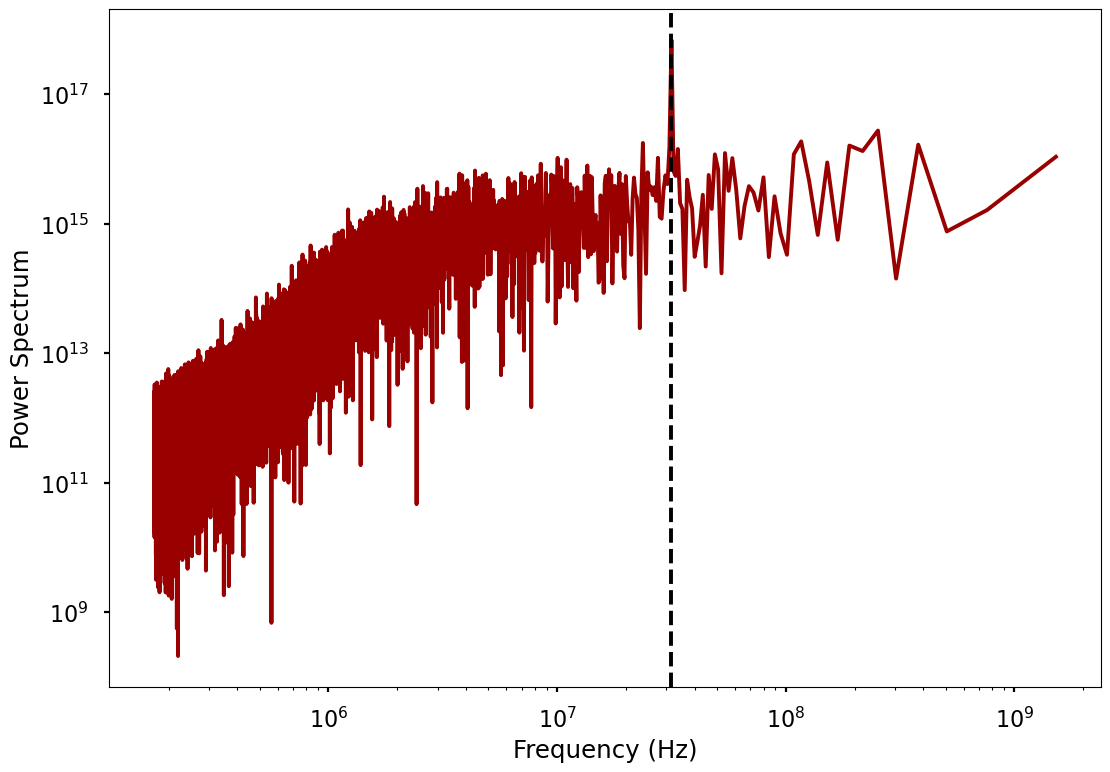

In [43]:
""" Plot the power spectrum of the data with the x-axis as period instead. """

""" Plot the power spectrum of the data. """

#convert time to seconds
time_seconds = (data['date']-data['date'][0]).dt.total_seconds()

# get power spectrum
freqs, cfm_power = power_spectrum(data['flow'], time_seconds)

#plots power spectrum
fig, ax = plot_power_spectrum(1/freqs,cfm_power) #period is inverse of frequency

#plot a line at the frequency of the test signal
ax.axvline((60*60*24*365.25), color = 'black', linestyle = '--') #get rid of 1/time

plt.show()
